In [ ]:
Simport numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("uciml/german-credit")

print(path)

100%|██████████| 10.9k/10.9k [00:00<00:00, 8.77MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/uciml/german-credit/versions/1


In [ ]:
import os

os.listdir(path)

['german_credit_data.csv']

In [ ]:
# Load dataset
df = pd.read_csv(path + "/german_credit_data.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
# Shape of dataset
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
df.info()

Shape: (1000, 10)

Columns:
Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [ ]:
!wget -O german.data https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data

--2026-07-29 12:16:31--  https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘german.data’

german.data             [ <=>                ]  77.92K  --.-KB/s    in 0.02s   

2026-07-29 12:16:31 (3.65 MB/s) - ‘german.data’ saved [79793]



In [ ]:
column_names = [
    'Status', 'Duration', 'CreditHistory', 'Purpose', 'CreditAmount',
    'Savings', 'EmploymentSince', 'InstallmentRate', 'PersonalStatusSex',
    'OtherDebtors', 'ResidenceSince', 'Property', 'Age',
    'OtherInstallmentPlans', 'Housing', 'ExistingCredits', 'Job',
    'PeopleLiable', 'Telephone', 'ForeignWorker', 'Class'
]

df = pd.read_csv(
    "german.data",
    sep=' ',
    header=None,
    names=column_names
)

df.head()

,Status,Duration,CreditHistory,Purpose,CreditAmount,Savings,EmploymentSince,InstallmentRate,PersonalStatusSex,OtherDebtors,...,Property,Age,OtherInstallmentPlans,Housing,ExistingCredits,Job,PeopleLiable,Telephone,ForeignWorker,Class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [ ]:
df.shape


(1000, 21)

In [ ]:
df["Class"].value_counts()

,count
Class,
1,700
2,300


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Status                 1000 non-null   object
 1   Duration               1000 non-null   int64 
 2   CreditHistory          1000 non-null   object
 3   Purpose                1000 non-null   object
 4   CreditAmount           1000 non-null   int64 
 5   Savings                1000 non-null   object
 6   EmploymentSince        1000 non-null   object
 7   InstallmentRate        1000 non-null   int64 
 8   PersonalStatusSex      1000 non-null   object
 9   OtherDebtors           1000 non-null   object
 10  ResidenceSince         1000 non-null   int64 
 11  Property               1000 non-null   object
 12  Age                    1000 non-null   int64 
 13  OtherInstallmentPlans  1000 non-null   object
 14  Housing                1000 non-null   object
 15  ExistingCredits       

In [ ]:
df.isnull().sum()

,0
Status,0
Duration,0
CreditHistory,0
Purpose,0
CreditAmount,0
Savings,0
EmploymentSince,0
InstallmentRate,0
PersonalStatusSex,0
OtherDebtors,0


In [ ]:
# Convert target: Good Credit = 1, Bad Credit = 0
df["Class"] = df["Class"].map({1: 1, 2: 0})

df["Class"].value_counts()

,count
Class,
1,700
0,300


In [ ]:
X = df.drop("Class", axis=1).copy()
y = df["Class"]

In [ ]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in X.columns:
    if X[col].dtype == "object":
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        encoders[col] = le

print(encoders.keys())

dict_keys(['Status', 'CreditHistory', 'Purpose', 'Savings', 'EmploymentSince', 'PersonalStatusSex', 'OtherDebtors', 'Property', 'OtherInstallmentPlans', 'Housing', 'Job', 'Telephone', 'ForeignWorker'])


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report")
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.75
Precision: 0.8082191780821918
Recall   : 0.8428571428571429
F1 Score : 0.8251748251748252
ROC AUC  : 0.7985714285714286

Classification Report
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        60
           1       0.81      0.84      0.83       140

    accuracy                           0.75       200
   macro avg       0.70      0.69      0.69       200
weighted avg       0.74      0.75      0.75       200



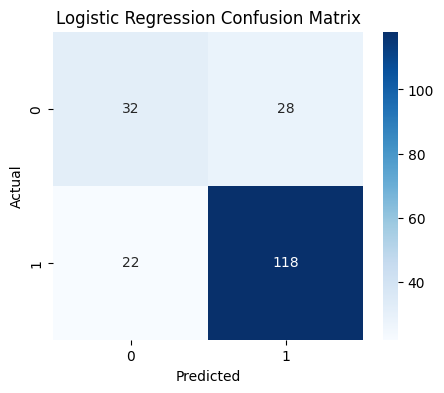

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

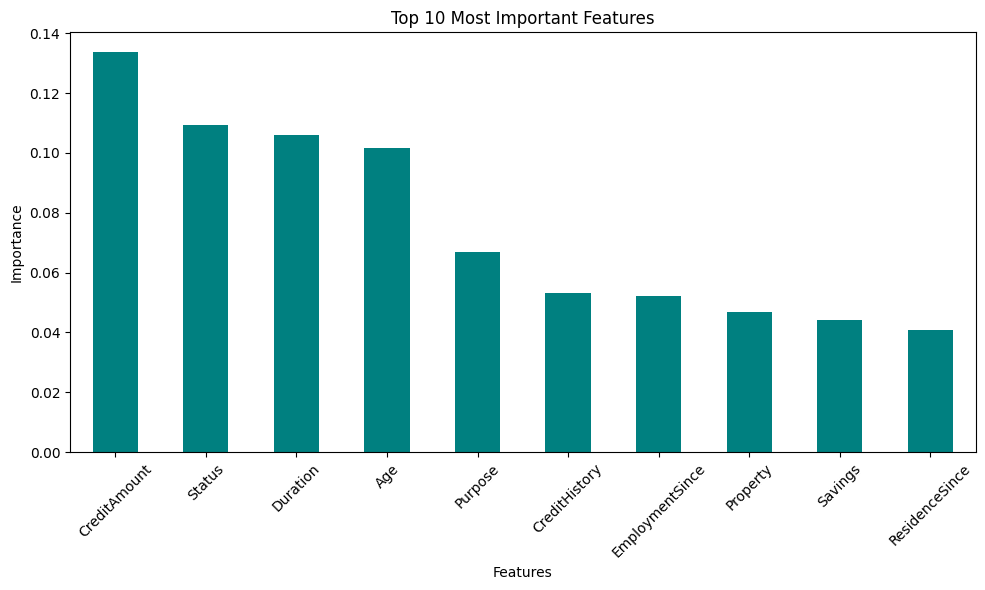

In [ ]:
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind="bar", color="teal")
plt.title("Top 10 Most Important Features")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print(user_data)
print(user_data.dtypes)

  Status  Duration CreditHistory Purpose  CreditAmount Savings  \
0    A14        12           A32     A43          1500     A65   

  EmploymentSince  InstallmentRate PersonalStatusSex OtherDebtors  \
0             A75                2               A93         A101   

   ResidenceSince Property  Age OtherInstallmentPlans Housing  \
0               4     A123   40                  A143    A152   

   ExistingCredits   Job  PeopleLiable Telephone ForeignWorker  
0                1  A173             1      A192          A201  
Status                   object
Duration                  int64
CreditHistory            object
Purpose                  object
CreditAmount              int64
Savings                  object
EmploymentSince          object
InstallmentRate           int64
PersonalStatusSex        object
OtherDebtors             object
ResidenceSince            int64
Property                 object
Age                       int64
OtherInstallmentPlans    object
Housing            

In [ ]:
print(encoders)

{'Status': LabelEncoder(), 'CreditHistory': LabelEncoder(), 'Purpose': LabelEncoder(), 'Savings': LabelEncoder(), 'EmploymentSince': LabelEncoder(), 'PersonalStatusSex': LabelEncoder(), 'OtherDebtors': LabelEncoder(), 'Property': LabelEncoder(), 'OtherInstallmentPlans': LabelEncoder(), 'Housing': LabelEncoder(), 'Job': LabelEncoder(), 'Telephone': LabelEncoder(), 'ForeignWorker': LabelEncoder()}


In [ ]:
for col in encoders.keys():
    user_data[col] = encoders[col].transform(user_data[col])

print(user_data)
print(user_data.dtypes)

   Status  Duration  CreditHistory  Purpose  CreditAmount  Savings  \
0       3        12              2        4          1500        4   

   EmploymentSince  InstallmentRate  PersonalStatusSex  OtherDebtors  \
0                4                2                  2             0   

   ResidenceSince  Property  Age  OtherInstallmentPlans  Housing  \
0               4         2   40                      2        1   

   ExistingCredits  Job  PeopleLiable  Telephone  ForeignWorker  
0                1    2             1          1              0  
Status                   int64
Duration                 int64
CreditHistory            int64
Purpose                  int64
CreditAmount             int64
Savings                  int64
EmploymentSince          int64
InstallmentRate          int64
PersonalStatusSex        int64
OtherDebtors             int64
ResidenceSince           int64
Property                 int64
Age                      int64
OtherInstallmentPlans    int64
Housing    

🎉 Prediction Result
✅ Good Credit Risk
Confidence Score: 97.50%


In [ ]:
user_data = pd.DataFrame({
    'Status': ['A14'],
    'Duration': [12],
    'CreditHistory': ['A32'],
    'Purpose': ['A43'],
    'CreditAmount': [1500],
    'Savings': ['A65'],
    'EmploymentSince': ['A75'],
    'InstallmentRate': [2],
    'PersonalStatusSex': ['A93'],
    'OtherDebtors': ['A101'],
    'ResidenceSince': [4],
    'Property': ['A123'],
    'Age': [40],
    'OtherInstallmentPlans': ['A143'],
    'Housing': ['A152'],
    'ExistingCredits': [1],
    'Job': ['A173'],
    'PeopleLiable': [1],
    'Telephone': ['A192'],
    'ForeignWorker': ['A201']
})

In [ ]:
prediction = rf.predict(user_data)[0]
probability = rf.predict_proba(user_data)[0]

print("🎉 Prediction Result")

if prediction == 1:
    print("✅ Good Credit Risk")
    print(f"Confidence Score: {probability[1]*100:.2f}%")
else:
    print("❌ Bad Credit Risk")
    print(f"Confidence Score: {probability[0]*100:.2f}%")

🎉 Prediction Result
✅ Good Credit Risk
Confidence Score: 97.50%
